# Principal Component Analysis (PCA) via Singular Value Decomposition (SVD)
in this example we will show how to perform PCA using SVD.
1. make a fake dataset
2. perform SVD
3. show how the results overlay the old datao
4. show how the new data is represented in the new basis.

## make fake dataset 
a fake dataset where we know it's shape and properties, so that we can test PCA on a question where we know the answer

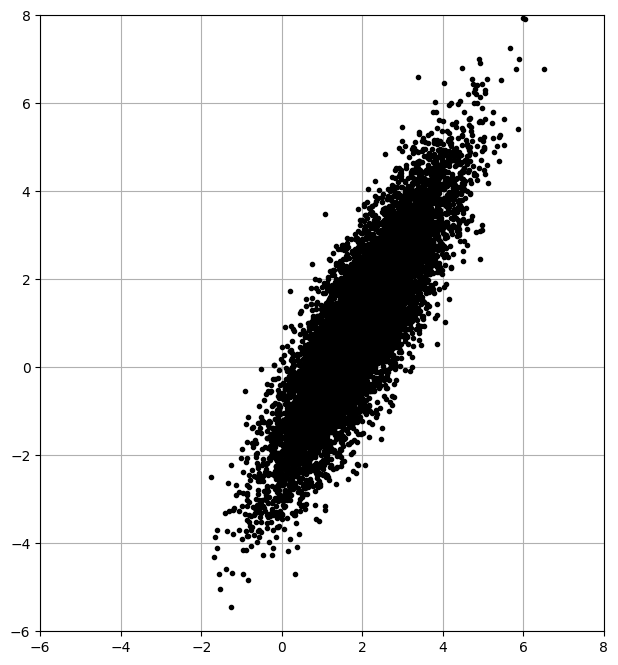

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
plt.rcParams['figure.figsize'] = [16, 8]

xC = np.array([2, 1])     # center of data (mean)
sig = np.array([2, 0.5])  # spread of data along the principal axes
_theta = np.pi/3          # rotate cloud by pi/3

R = np.array([[np.cos(_theta), -np.sin(_theta)],  # rotation matrix
              [np.sin(_theta), np.cos(_theta)]])

nPoints = 10000 # create 10,000 points
X = R @ np.diag(sig) @ np.random.randn(2, nPoints) + np.diag(xC) @ np.ones((2, nPoints)) # create data and rotate

fig = plt.figure()
ax1 = fig.add_subplot(121)
ax1.plot(X[0, :], X[1, :], '.', color='k')
ax1.grid()
plt.xlim((-6, 8))
plt.ylim((-6, 8))
plt.show()

## calculate PCA

In [2]:
Xavg = np.mean(X, axis=1)                  # Compute the mean of the data
distance_from_mean = X - np.tile(Xavg, (nPoints, 1)).T      # For each datapoint in X, subtract the mean (standarize the data)
normalized_distance_from_mean = distance_from_mean / np.sqrt(nPoints)  # Normalize the data

# find principal components via SVD - Singular Value Decomposition
# U, S, VT = np.linalg.svd(normalized_distance_from_mean, full_matrices=0)
PCA_U_axes, PCA_S_sigmas, PCA_VT_orthonormal_transformed_data = np.linalg.svd(normalized_distance_from_mean, full_matrices=0)
U = PCA_U_axes
S = PCA_S_sigmas
VT = PCA_VT_orthonormal_transformed_data
"""
U represents the axes / directions which maximize the variance in the data
S represents the amount of variance in each direction (magnitude of the axes vectors)
VT is the transformed data into orthonormal space
"""
theta = 2 * np.pi * np.arange(0, 1, 0.01)

## plot how pca overlays original data

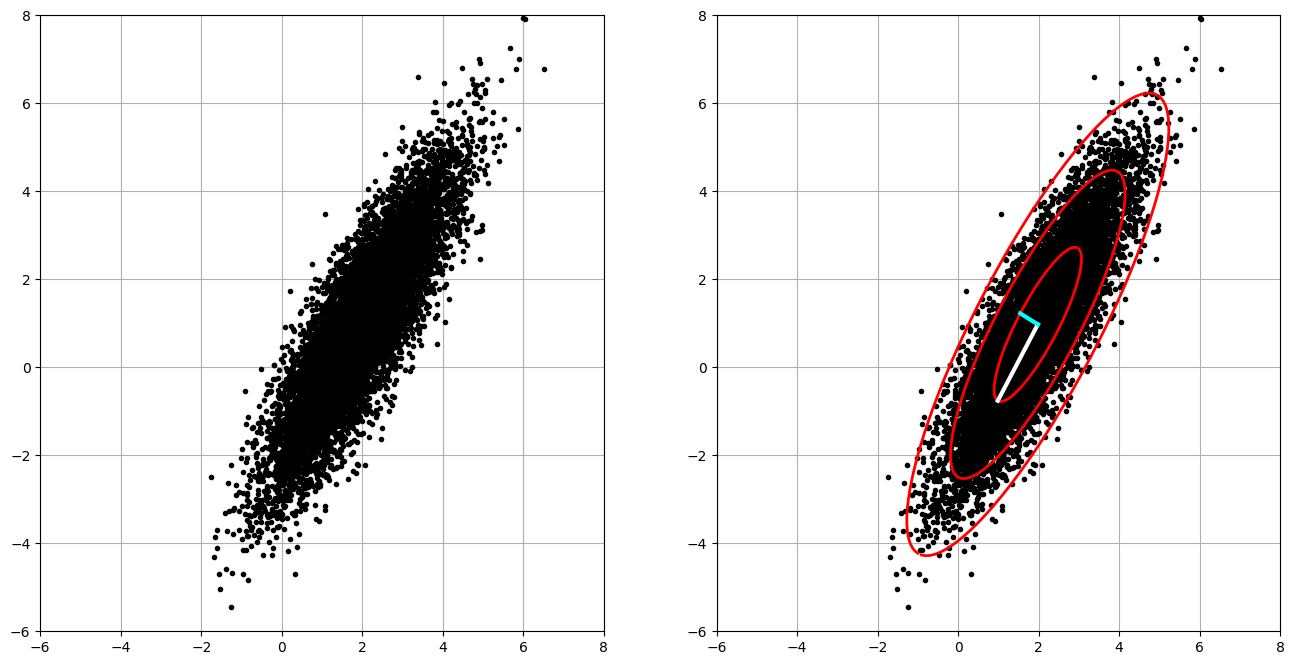

In [10]:
# plot raw data again
fig = plt.figure()
ax1 = fig.add_subplot(121)
ax1.plot(X[0, :], X[1, :], 'k.')
ax1.grid()
plt.xlim((-6, 8))
plt.ylim((-6, 8))

# plot raw data in new frame to overlay PCA onto
ax2 = fig.add_subplot(122)
ax2.plot(X[0, :], X[1, :], 'k.')  # plot data to overlay PCA
ax2.grid()
plt.xlim((-6, 8))
plt.ylim((-6, 8))

# confidence interval overlays
Xstd = PCA_U_axes @ np.diag(PCA_S_sigmas) @ np.array([np.cos(theta), np.sin(theta)])
ax2.plot(Xavg[0] + Xstd[0, :], Xavg[1] + Xstd[1, :], '-', color='r', linewidth=2)       # plot 1-std confidence interval
ax2.plot(Xavg[0] + 2*Xstd[0, :], Xavg[1] + 2*Xstd[1, :], '-', color='r', linewidth=2)   # plot 2-std confidence interval
ax2.plot(Xavg[0] + 3*Xstd[0, :], Xavg[1] + 3*Xstd[1, :], '-', color='r', linewidth=2)   # plot 3-std confidence interval

# plot prinicpal components U[:,0]S[0] and U[:,1]S[1]
ax2.plot(np.array([Xavg[0], Xavg[0] + PCA_U_axes[0, 0] * PCA_S_sigmas[0]]),
         np.array([Xavg[1], Xavg[1] + PCA_U_axes[1, 0] * PCA_S_sigmas[0]]), color='w', linewidth=3)
ax2.plot(np.array([Xavg[0], Xavg[0] + PCA_U_axes[0, 1] * PCA_S_sigmas[1]]),
         np.array([Xavg[1], Xavg[1] + PCA_U_axes[1, 1] * PCA_S_sigmas[1]]), color='cyan', linewidth=3)

plt.show()

## plot PCA results

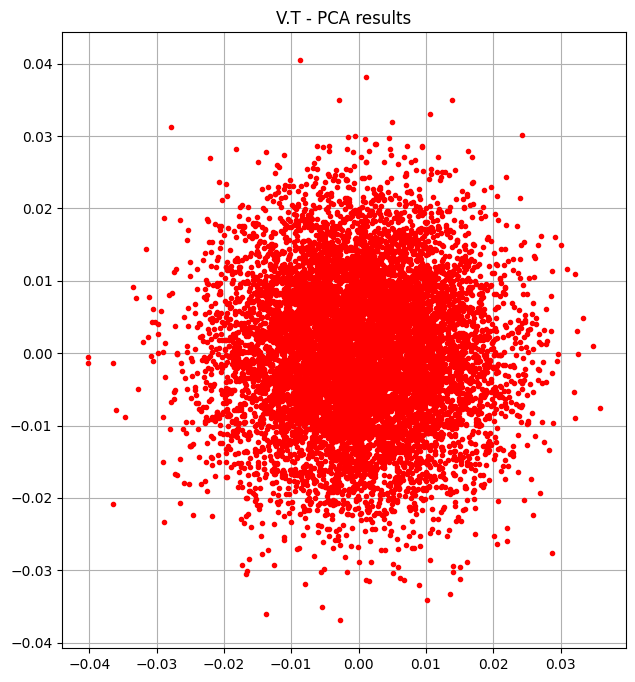

In [6]:
# plot VT
fig = plt.figure()
ax1 = fig.add_subplot(121)
ax1.plot(VT[0, :], VT[1, :], 'r.', linewidth=1)
# add title
ax1.set_title('V.T - PCA results')
ax1.grid()
plt.show()